In [22]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("bhavikjikadara/dog-and-cat-classification-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'dog-and-cat-classification-dataset' dataset.
Path to dataset files: /kaggle/input/dog-and-cat-classification-dataset


In [23]:
!ls {path}

PetImages


In [24]:
dataset_path = path + "/PetImages"
!ls {dataset_path}

Cat  Dog


## 1. ตรวจโครงสร้างและดูตัวอย่าง
### dataset-image-visualizer

🔍 Inspecting dataset at: /kaggle/input/dog-and-cat-classification-dataset/PetImages


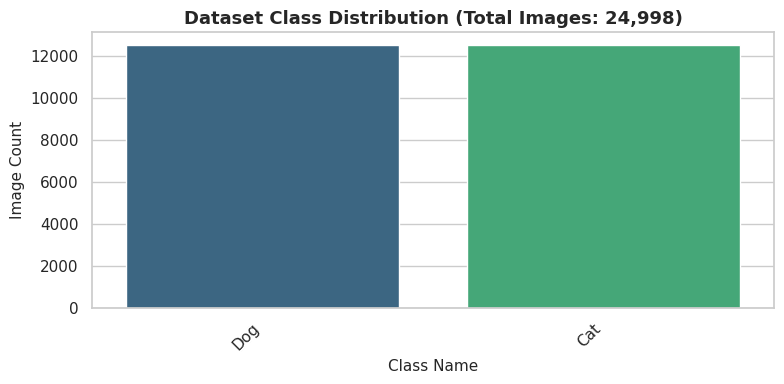

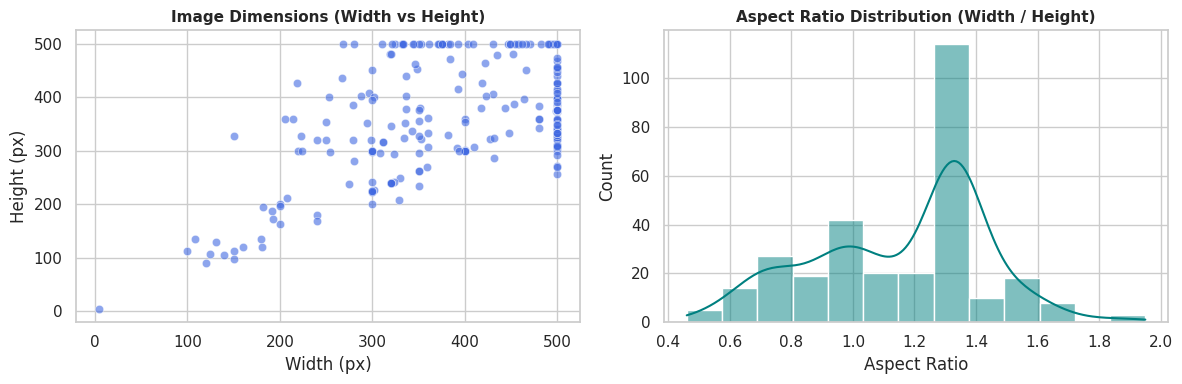

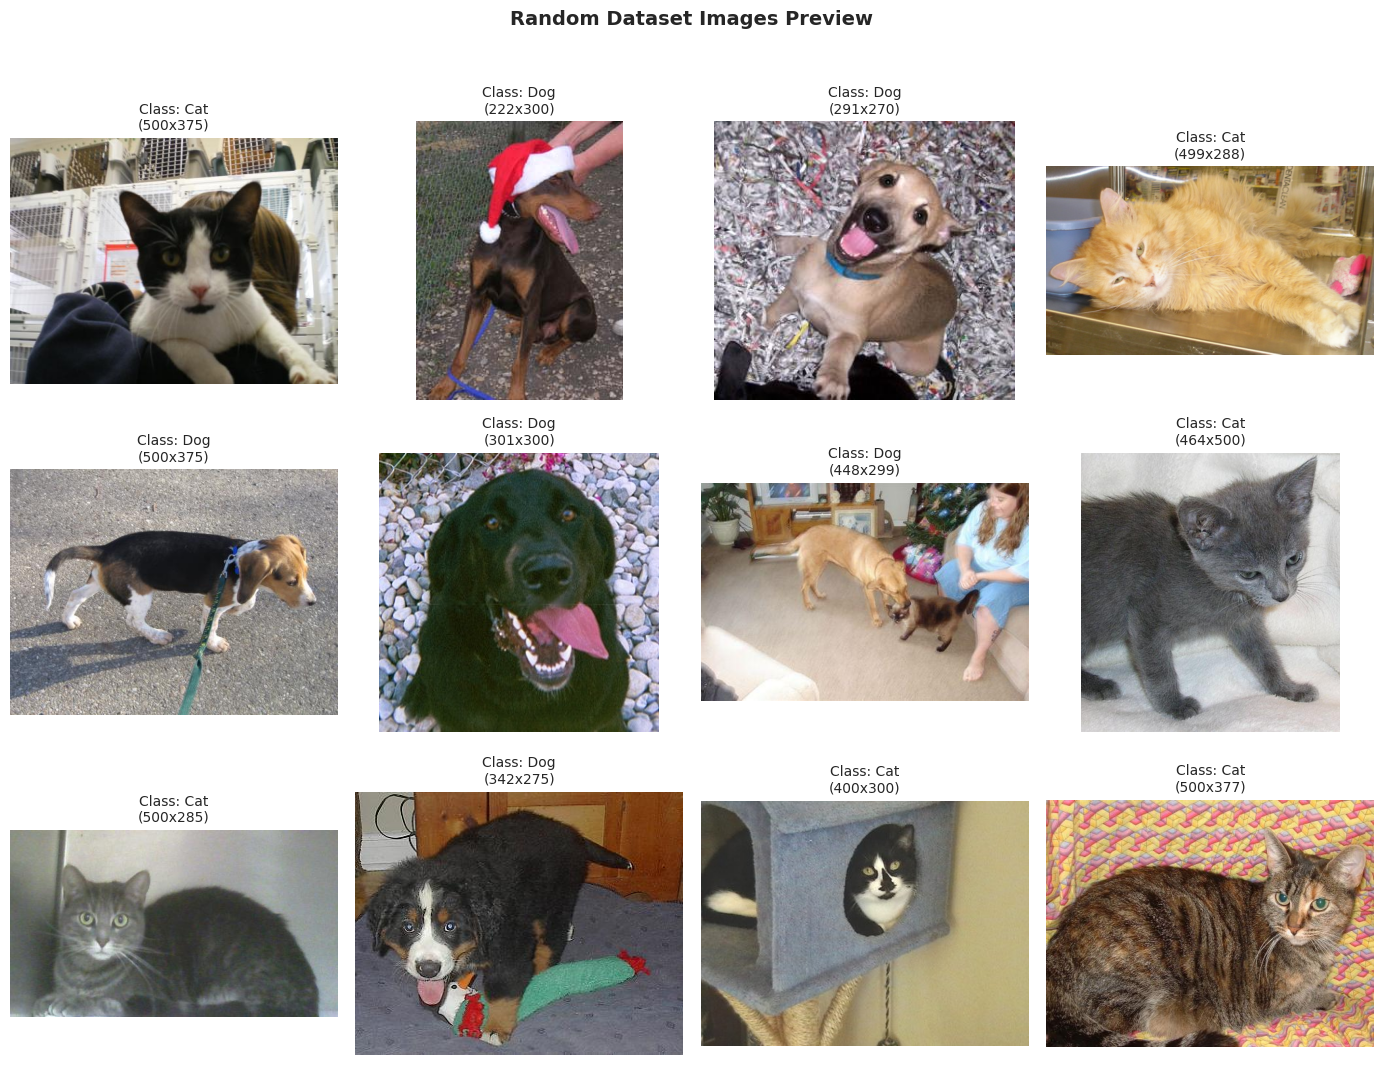

In [ ]:
import os
import random
from pathlib import Path
from typing import List, Optional, Tuple, Union
import pandas as pd
from PIL import Image
import seaborn as sns

import matplotlib.pyplot as plt


def scan_image_dataset(dataset_path: Union[str, Path]) -> List[Tuple[str, str]]:
    """Scans a directory path structured by class subfolders or flat image folders."""
    data_path = Path(dataset_path)
    if not data_path.exists():
        raise FileNotFoundError(f"Dataset path not found: {data_path}")

    valid_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    image_label_pairs = []

    subdirs = [d for d in data_path.iterdir() if d.is_dir()]
    if subdirs:
        for subdir in subdirs:
            cls_name = subdir.name
            for file in subdir.rglob("*.*"):
                if file.suffix.lower() in valid_extensions:
                    image_label_pairs.append((str(file), cls_name))
    else:
        for file in data_path.glob("*.*"):
            if file.suffix.lower() in valid_extensions:
                image_label_pairs.append((str(file), "Uncategorized"))

    return image_label_pairs


def plot_random_dataset_images(
    dataset_path: Union[str, Path],
    num_samples: int = 12,
    cols: int = 4,
    seed: Optional[int] = None,
) -> None:
    """Samples random images and displays them in a grid with class labels and resolution."""
    if seed is not None:
        random.seed(seed)

    image_label_pairs = scan_image_dataset(dataset_path)
    if not image_label_pairs:
        print(f"⚠️ No valid image files found in '{dataset_path}'.")
        return

    selected = random.sample(image_label_pairs, min(num_samples, len(image_label_pairs)))
    rows = (len(selected) + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.5, rows * 3.5))
    axes = axes.flatten() if len(selected) > 1 else [axes]

    for idx, (img_path, label) in enumerate(selected):
        try:
            with Image.open(img_path) as img:
                rgb_img = img.convert("RGB")
                axes[idx].imshow(rgb_img)
                axes[idx].set_title(f"Class: {label}\n({img.width}x{img.height})", fontsize=10)
        except Exception:
            axes[idx].set_title(f"Error loading:\n{label}", color="red", fontsize=9)
        axes[idx].axis("off")

    for j in range(len(selected), len(axes)):
        axes[j].axis("off")

    plt.suptitle("Random Dataset Images Preview", fontsize=14, y=1.02, fontweight="bold")
    plt.tight_layout()
    plt.show()


def plot_dataset_statistics(
    dataset_path: Union[str, Path],
    max_dim_samples: int = 300,
) -> None:
    """Plots class balance bar plot and image dimension/aspect ratio distributions."""
    image_label_pairs = scan_image_dataset(dataset_path)
    if not image_label_pairs:
        print(f"⚠️ No valid images found in '{dataset_path}'.")
        return

    sns.set_theme(style="whitegrid")

    # 1. Class Distribution Barplot
    labels = [pair[1] for pair in image_label_pairs]
    label_counts = pd.Series(labels).value_counts()

    plt.figure(figsize=(max(8, len(label_counts) * 0.5), 4))
    sns.barplot(x=label_counts.index, y=label_counts.values, hue=label_counts.index, palette="viridis", legend=False)
    plt.title(f"Dataset Class Distribution (Total Images: {len(image_label_pairs):,})", fontsize=13, fontweight="bold")
    plt.xlabel("Class Name", fontsize=11)
    plt.ylabel("Image Count", fontsize=11)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    # 2. Dimensions and Aspect Ratio Check
    sampled_for_dim = random.sample(image_label_pairs, min(max_dim_samples, len(image_label_pairs)))
    widths, heights, aspect_ratios = [], [], []

    for img_path, _ in sampled_for_dim:
        try:
            with Image.open(img_path) as img:
                w, h = img.size
                widths.append(w)
                heights.append(h)
                aspect_ratios.append(round(w / h, 2))
        except Exception:
            continue

    if widths:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        sns.scatterplot(x=widths, y=heights, alpha=0.6, color="royalblue", ax=axes[0])
        axes[0].set_title("Image Dimensions (Width vs Height)", fontsize=11, fontweight="bold")
        axes[0].set_xlabel("Width (px)")
        axes[0].set_ylabel("Height (px)")

        sns.histplot(aspect_ratios, kde=True, color="teal", ax=axes[1])
        axes[1].set_title("Aspect Ratio Distribution (Width / Height)", fontsize=11, fontweight="bold")
        axes[1].set_xlabel("Aspect Ratio")
        plt.tight_layout()
        plt.show()


def visualize_dataset(dataset_path: Union[str, Path], num_samples: int = 20) -> None:
    """Main visualization entry point executing random grid inspection and dataset metrics."""
    print(f"🔍 Inspecting dataset at: {dataset_path}")
    plot_dataset_statistics(dataset_path)
    plot_random_dataset_images(dataset_path, num_samples=num_samples)


visualize_dataset(dataset_path)

## 2. โหลด EfficientNet-B2 พร้อม pretrained weights และเปลี่ยน classifier
### pretrained-model-builder 

In [26]:
from typing import Any
import torch
from torchvision.models import get_model, get_model_weights

import torch.nn as nn


def create_pretrained_model(
    model_name: str,
    num_classes: int,
    freeze_backbone: bool = True,
    dropout: float = 0.2,
    seed: Optional[int] = 42,
) -> Tuple[nn.Module, Any]:
    """Creates a pretrained model, freezes the backbone, replaces the classifier head,

    and returns (model, transforms).
    """
    model_name_clean = model_name.strip().lower()

    # 1. Load weights and transforms
    weights_enum = get_model_weights(model_name_clean).DEFAULT
    model = get_model(model_name_clean, weights=weights_enum)
    transforms = weights_enum.transforms()

    # 2. Freeze backbone parameters
    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    # 3. Deterministic head replacement
    if seed is not None:
        torch.manual_seed(seed)

    # 4. Adapt classifier head for EfficientNet
    if hasattr(model, "classifier") and isinstance(model.classifier, nn.Sequential):
        last_idx = len(model.classifier) - 1
        for idx in reversed(range(len(model.classifier))):
            if isinstance(model.classifier[idx], nn.Linear):
                last_idx = idx
                break

        in_features = model.classifier[last_idx].in_features
        model.classifier[last_idx] = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(in_features=in_features, out_features=num_classes),
        )
    elif hasattr(model, "fc") and isinstance(model.fc, nn.Linear):
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features=in_features, out_features=num_classes)
    else:
        raise NotImplementedError(f"Classifier adaptation not mapped for '{model_name}'.")

    return model, transforms


# Create EfficientNet-B2 with 2 output classes
model, transform = create_pretrained_model(
    model_name="efficientnet_b2",
    num_classes=2,
    freeze_backbone=True,
    dropout=0.2,
)

print(f"Model architecture: efficientnet_b2")
print(f"Base transforms:\n{transform}")

Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:00<00:00, 250MB/s]


Model architecture: efficientnet_b2
Base transforms:
ImageClassification(
    crop_size=[288]
    resize_size=[288]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)


In [27]:
model

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [ ]:
import subprocess
import sys
from typing import Sequence


try:
    from torchinfo import summary
    print("✅ Successfully imported summary from torchinfo.")
except ImportError:
    print("📦 'torchinfo' is not installed. Installing now...")
    try:
        get_ipython().system("pip install torchinfo")
        from torchinfo import summary
    except NameError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "torchinfo"])
    print("✅ Successfully imported summary from torchinfo.")


def inspect_model(
    model: nn.Module,
    input_size: Tuple[int, ...] = (1, 3, 288, 288),
    col_names: Sequence[str] = ("input_size", "output_size", "num_params", "trainable"),
    depth: int = 3,
    verbose: int = 1,
):
    """Summarizes a PyTorch model ensuring correct device allocation and input shape."""
    device = next(model.parameters()).device if list(model.parameters()) else "cpu"
    model.eval()

    return summary(
        model=model,
        input_size=input_size,
        device=device,
        col_names=list(col_names),
        depth=depth,
    )


inspect_model(model)

## 3. สร้าง Dataset, DataLoader และ Image Transform
### dataset-dataloader-builder

In [ ]:
from torch.utils.data import DataLoader, Dataset, Subset, random_split
from torchvision import datasets

class DatasetFromSubset(Dataset):
    """Wrapper to apply transforms on subsets derived from random_split."""

    def __init__(self, subset: Subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, idx: int):
        x, y = self.subset[idx]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self) -> int:
        return len(self.subset)


def create_dataloaders(
    dataset_path: Union[str, Path],
    transform=transform,
    batch_size: int = 32,
    train_split: float = 0.8,
    val_split: float = 0.1,
    test_split: float = 0.1,
    num_workers: int = 2,
    seed: int = 42,
) -> Tuple[DataLoader, DataLoader, DataLoader, List[str]]:
    """Builds train, val, and test DataLoaders (80/10/10 split) using the specified transform."""
    data_path = Path(dataset_path)
    if not data_path.exists():
        raise FileNotFoundError(f"Dataset path not found: {data_path}")

    raw_dataset = datasets.ImageFolder(data_path, transform=None)
    class_names = raw_dataset.classes

    total_size = len(raw_dataset)
    val_size = int(total_size * val_split)
    test_size = int(total_size * test_split)
    train_size = total_size - val_size - test_size

    generator = torch.Generator().manual_seed(seed)
    train_sub, val_sub, test_sub = random_split(
        raw_dataset, [train_size, val_size, test_size], generator=generator
    )

    train_data = DatasetFromSubset(train_sub, transform=transform)
    val_data = DatasetFromSubset(val_sub, transform=transform)
    test_data = DatasetFromSubset(test_sub, transform=transform)

    train_dataloader = DataLoader(
        train_data,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available(),
        persistent_workers=num_workers > 0,
    )

    val_dataloader = DataLoader(
        val_data,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available(),
        persistent_workers=num_workers > 0,
    )

    test_dataloader = DataLoader(
        test_data,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available(),
    )

    return train_dataloader, val_dataloader, test_dataloader, class_names, raw_dataset


train_loader, val_loader, test_loader, class_names, raw_dataset = create_dataloaders(
    dataset_path=dataset_path,
    transform=transform,
    train_split=0.8,
    val_split=0.1,
    test_split=0.1,
)

print(f"Classes: {class_names}")
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

Classes: ['Cat', 'Dog']
Train batches: 625 | Val batches: 79 | Test batches: 79


In [ ]:
print(f"total dataset {len(raw_dataset)} ")
print(f"train dataset {len(train_loader.dataset)} ")
print(f"validation dataset {len(val_loader.dataset)} ")
print(f"test dataset {len(test_loader.dataset)} ")

In [29]:
batch_image, batch_labels = next(iter(train_loader))
print(f"Batch image shape: {batch_image.shape}")
print(f"Batch labels shape: {batch_labels.shape}")

Batch image shape: torch.Size([32, 3, 288, 288])
Batch labels shape: torch.Size([32])


/usr/local/lib/python3.13/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
/usr/local/lib/python3.13/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


In [30]:
pred = model(batch_image)
print(f"Prediction shape: {pred.shape}")
print(f"Prediction: {pred}")

Prediction shape: torch.Size([32, 2])
Prediction: tensor([[-0.1867,  0.2875],
        [ 0.0459, -0.1762],
        [-0.2286, -0.1879],
        [-0.1867, -0.2075],
        [-0.0555, -0.0923],
        [-0.2314, -0.3425],
        [-0.3870, -0.2544],
        [-0.4336, -0.2524],
        [-0.0495, -0.3308],
        [-0.5571, -0.4215],
        [-0.0368,  0.2606],
        [-0.0455, -0.2090],
        [-0.2699, -0.2956],
        [-0.2646, -0.1462],
        [-0.0121,  0.0693],
        [ 0.0288, -0.5126],
        [ 0.0594,  0.1421],
        [-0.0404, -0.0899],
        [-0.3588,  0.4149],
        [-0.1637,  0.3000],
        [ 0.2194, -0.1522],
        [-0.4096,  0.2825],
        [-0.1483, -0.4028],
        [-0.4708,  0.1786],
        [-0.0789,  0.0328],
        [ 0.0813,  0.2694],
        [-0.1778,  0.1248],
        [-0.3334, -0.1185],
        [-0.2554, -0.0678],
        [-0.1496, -0.2246],
        [-0.0847, -0.1185],
        [-0.1634,  0.0810]], grad_fn=<AddmmBackward0>)


## 4. Fine-tune โมเดล พร้อมดูค่า Loss และ Accuracy
### model-trainer-visualizer

🚀 Training started on device: cuda
Epoch [01/03] | Train Loss: 0.1300 - Train Acc: 95.45% | Val Loss: 0.0570 - Val Acc: 98.24%
Epoch [02/03] | Train Loss: 0.0910 - Train Acc: 96.51% | Val Loss: 0.0479 - Val Acc: 98.32%
Epoch [03/03] | Train Loss: 0.0895 - Train Acc: 96.56% | Val Loss: 0.0456 - Val Acc: 98.20%


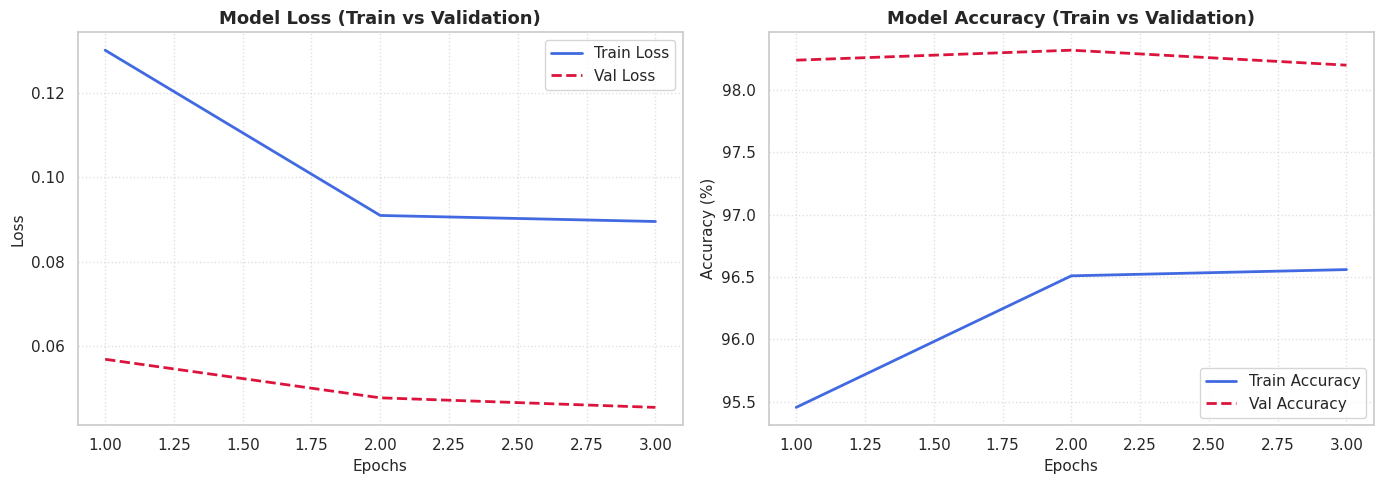

In [31]:
import copy
from typing import Dict

def setup_loss_and_optimizer(
    model: nn.Module,
    problem_type: str = "multiclass",
    learning_rate: float = 1e-3,
    weight_decay: float = 1e-4,
    label_smoothing: float = 0.0,
) -> Tuple[nn.Module, torch.optim.Optimizer]:
    """Configures task-appropriate criterion and optimizer."""
    if problem_type.lower() == "multiclass":
        loss_fn = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    elif problem_type.lower() == "binary":
        loss_fn = nn.BCEWithLogitsLoss()
    else:
        raise ValueError("problem_type must be either 'multiclass' or 'binary'")

    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.Adam(
        params=trainable_params, lr=learning_rate, weight_decay=weight_decay
    )
    return loss_fn, optimizer


class EarlyStopping:
    """Monitors validation loss to stop early and restore best weights."""

    def __init__(
        self,
        patience: int = 5,
        min_delta: float = 1e-4,
        monitor: str = "val_loss",
        mode: str = "min",
        restore_best_weights: bool = True,
    ):
        self.patience = patience
        self.min_delta = min_delta
        self.monitor = monitor
        self.mode = mode
        self.restore_best_weights = restore_best_weights
        self.counter = 0
        self.best_score: Optional[float] = None
        self.early_stop = False
        self.best_weights: Optional[Dict[str, torch.Tensor]] = None

    def __call__(self, current_metric: float, model: nn.Module) -> bool:
        score = -current_metric if self.mode == "min" else current_metric

        if self.best_score is None:
            self.best_score = score
            self.best_weights = copy.deepcopy(model.state_dict())
        elif score < self.best_score + self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.best_weights = copy.deepcopy(model.state_dict())
            self.counter = 0

        return self.early_stop

    def restore_model(self, model: nn.Module) -> None:
        if self.restore_best_weights and self.best_weights is not None:
            model.load_state_dict(self.best_weights)


def train_model(
    model: nn.Module,
    train_dataloader: DataLoader,
    val_dataloader: DataLoader,
    optimizer: torch.optim.Optimizer,
    loss_fn: nn.Module,
    epochs: int = 20,
    device: Optional[Union[str, torch.device]] = None,
    patience: int = 5,
    scheduler: Optional[torch.optim.lr_scheduler._LRScheduler] = None,
) -> Tuple[nn.Module, Dict[str, List[float]]]:
    """PyTorch training and validation loop with Early Stopping and Metric History."""
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    early_stopper = EarlyStopping(
        patience=patience, monitor="val_loss", mode="min", restore_best_weights=True
    )

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    print(f"🚀 Training started on device: {device}")
    for epoch in range(1, epochs + 1):
        # Training Phase
        model.train()
        running_train_loss = 0.0
        train_correct = 0
        train_total = 0

        for X, y in train_dataloader:
            X, y = X.to(device), y.to(device)

            optimizer.zero_grad()
            outputs = model(X)
            loss = loss_fn(outputs, y)
            preds = torch.argmax(outputs, dim=1)

            loss.backward()
            optimizer.step()

            running_train_loss += loss.item() * X.size(0)
            train_correct += (preds == y).sum().item()
            train_total += X.size(0)

        epoch_train_loss = running_train_loss / train_total
        epoch_train_acc = (train_correct / train_total) * 100.0

        # Validation Phase
        model.eval()
        running_val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.inference_mode():
            for X_val, y_val in val_dataloader:
                X_val, y_val = X_val.to(device), y_val.to(device)
                val_outputs = model(X_val)
                v_loss = loss_fn(val_outputs, y_val)
                v_preds = torch.argmax(val_outputs, dim=1)

                running_val_loss += v_loss.item() * X_val.size(0)
                val_correct += (v_preds == y_val).sum().item()
                val_total += X_val.size(0)

        epoch_val_loss = running_val_loss / val_total
        epoch_val_acc = (val_correct / val_total) * 100.0

        if scheduler is not None:
            scheduler.step()

        history["train_loss"].append(epoch_train_loss)
        history["train_acc"].append(epoch_train_acc)
        history["val_loss"].append(epoch_val_loss)
        history["val_acc"].append(epoch_val_acc)

        print(
            f"Epoch [{epoch:02d}/{epochs:02d}] | "
            f"Train Loss: {epoch_train_loss:.4f} - Train Acc: {epoch_train_acc:.2f}% | "
            f"Val Loss: {epoch_val_loss:.4f} - Val Acc: {epoch_val_acc:.2f}%"
        )

        if early_stopper(epoch_val_loss, model):
            print(f"⏹️ Early stopping triggered at Epoch {epoch}. Restoring best weights...")
            early_stopper.restore_model(model)
            break

    if not early_stopper.early_stop:
        early_stopper.restore_model(model)

    return model, history


def plot_training_history(history: Dict[str, List[float]]) -> None:
    """Plots Train vs Validation Loss and Accuracy side-by-side."""
    epochs_range = range(1, len(history["train_loss"]) + 1)
    plt.figure(figsize=(14, 5))

    # Loss curve
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history["train_loss"], label="Train Loss", color="royalblue", lw=2)
    plt.plot(epochs_range, history["val_loss"], label="Val Loss", color="crimson", lw=2, linestyle="--")
    plt.title("Model Loss (Train vs Validation)", fontsize=13, fontweight="bold")
    plt.xlabel("Epochs", fontsize=11)
    plt.ylabel("Loss", fontsize=11)
    plt.legend(frameon=True)
    plt.grid(True, linestyle=":", alpha=0.6)

    # Accuracy curve
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history["train_acc"], label="Train Accuracy", color="royalblue", lw=2)
    plt.plot(epochs_range, history["val_acc"], label="Val Accuracy", color="crimson", lw=2, linestyle="--")
    plt.title("Model Accuracy (Train vs Validation)", fontsize=13, fontweight="bold")
    plt.xlabel("Epochs", fontsize=11)
    plt.ylabel("Accuracy (%)", fontsize=11)
    plt.legend(frameon=True)
    plt.grid(True, linestyle=":", alpha=0.6)

    plt.tight_layout()
    plt.show()


# Set up criterion and optimizer
loss_fn, optimizer = setup_loss_and_optimizer(
    model=model,
    problem_type="multiclass",
    learning_rate=1e-3,
    weight_decay=1e-4,
)

# Train model
model, history = train_model(
    model=model,
    train_dataloader=train_loader,
    val_dataloader=val_loader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs=3,
    patience=3,
)

# Visualize curves
plot_training_history(history)

## 5. ประเมินโมเดลกับชุดทดสอบ
### model-test-evaluator

📊 TEST EVALUATION SUMMARY
Test Loss        : 0.0513
Total Samples    : 2,499
Correct Count    : 2,454 / 2,499
Test Accuracy    : 98.20%

Classification Report:

              precision    recall  f1-score   support

         Cat       0.98      0.98      0.98      1260
         Dog       0.98      0.98      0.98      1239

    accuracy                           0.98      2499
   macro avg       0.98      0.98      0.98      2499
weighted avg       0.98      0.98      0.98      2499



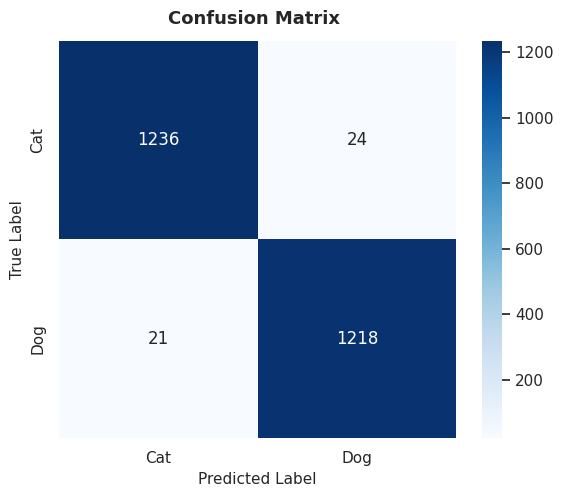

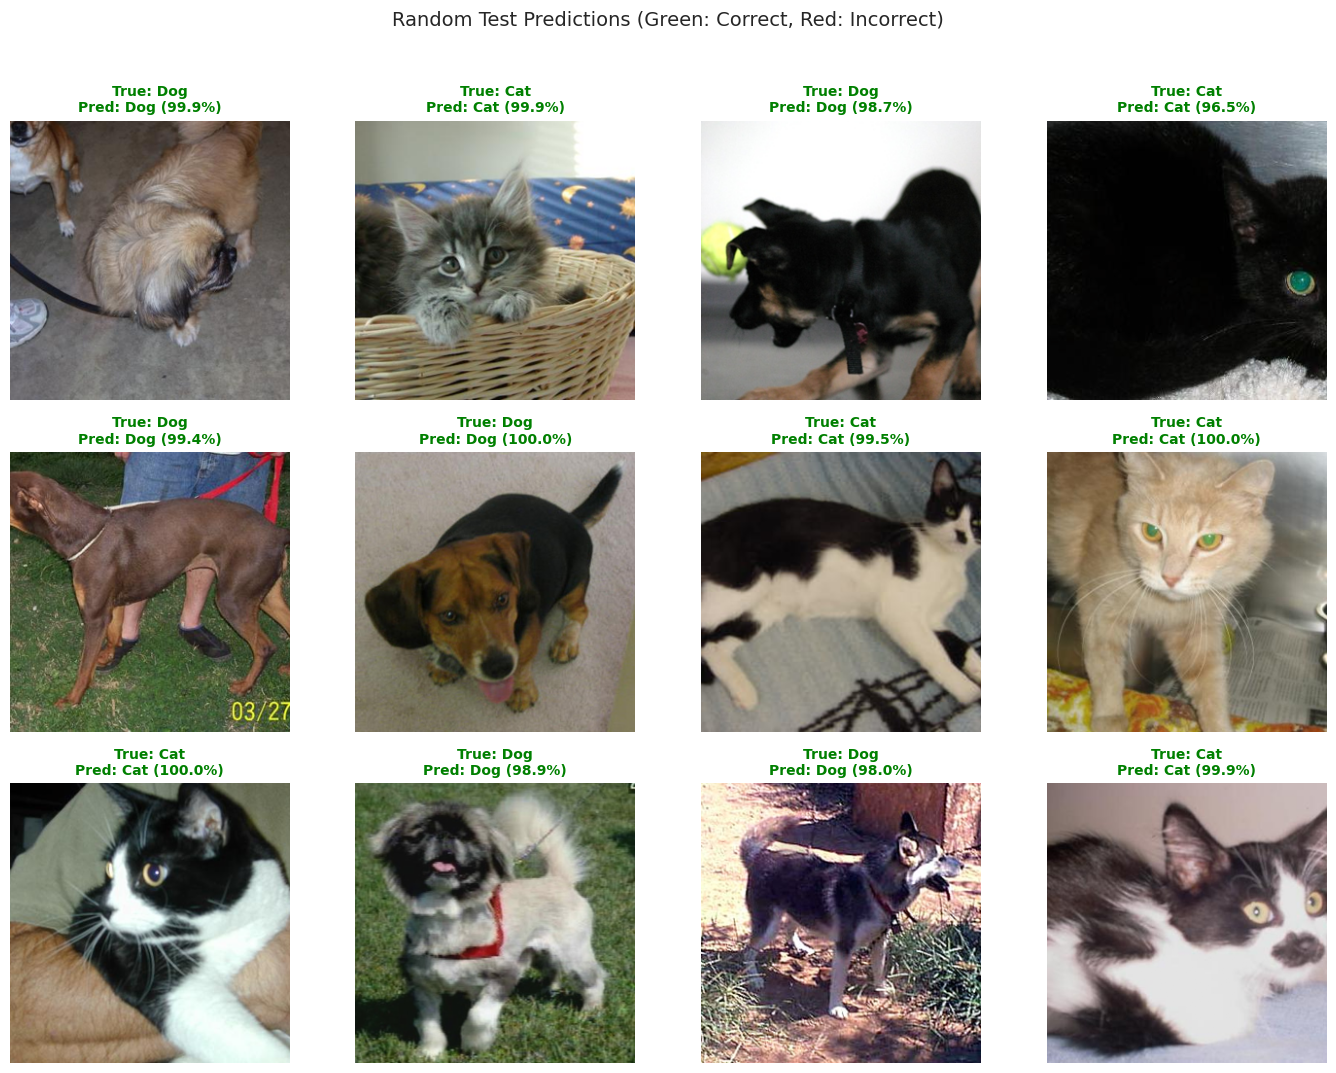

In [32]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

def evaluate_test_model(
    model: nn.Module,
    test_dataloader: DataLoader,
    class_names: List[str],
    loss_fn: Optional[nn.Module] = None,
    device: Optional[Union[str, torch.device]] = None,
) -> Tuple[float, int, int, np.ndarray, np.ndarray]:
    """Evaluates model performance over the test DataLoader."""
    if device is None:
        device = next(model.parameters()).device
    else:
        model = model.to(device)

    model.eval()
    total_correct = 0
    total_samples = 0
    running_loss = 0.0

    all_preds_list = []
    all_targets_list = []

    with torch.inference_mode():
        for X, y in test_dataloader:
            X, y = X.to(device), y.to(device)
            outputs = model(X)

            if loss_fn is not None:
                loss = loss_fn(outputs, y)
                running_loss += loss.item() * X.size(0)

            if outputs.ndim > 1 and outputs.shape[-1] > 1:
                preds = torch.argmax(outputs, dim=1)
            else:
                preds = (torch.sigmoid(outputs.squeeze(-1)) >= 0.5).long()

            total_correct += (preds == y).sum().item()
            total_samples += X.size(0)

            all_preds_list.extend(preds.cpu().numpy())
            all_targets_list.extend(y.cpu().numpy())

    all_preds = np.array(all_preds_list)
    all_targets = np.array(all_targets_list)
    test_acc = (total_correct / total_samples) * 100.0

    print("=" * 60)
    print("📊 TEST EVALUATION SUMMARY")
    print("=" * 60)
    if loss_fn is not None:
        print(f"Test Loss        : {running_loss / total_samples:.4f}")
    print(f"Total Samples    : {total_samples:,}")
    print(f"Correct Count    : {total_correct:,} / {total_samples:,}")
    print(f"Test Accuracy    : {test_acc:.2f}%")
    print("=" * 60)

    print("\nClassification Report:\n")
    print(classification_report(all_targets, all_preds, target_names=class_names))

    return test_acc, total_correct, total_samples, all_preds, all_targets


def plot_confusion_matrix(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    class_names: List[str],
    normalize: Optional[str] = None,
    figsize: Tuple[int, int] = (6, 5),
    cmap: str = "Blues",
) -> None:
    """Plots a labeled confusion matrix heatmap."""
    cm = confusion_matrix(y_true, y_pred, normalize=normalize)
    fmt = ".2f" if normalize else "d"

    plt.figure(figsize=figsize)
    sns.heatmap(
        cm,
        annot=True,
        fmt=fmt,
        cmap=cmap,
        xticklabels=class_names,
        yticklabels=class_names,
        cbar=True,
        square=True,
    )
    plt.title(f"Confusion Matrix {'(Normalized)' if normalize else ''}", fontsize=13, fontweight="bold", pad=12)
    plt.xlabel("Predicted Label", fontsize=11)
    plt.ylabel("True Label", fontsize=11)
    plt.tight_layout()
    plt.show()


def plot_random_predictions(
    model: nn.Module,
    test_dataloader: DataLoader,
    class_names: List[str],
    num_images: int = 12,
    cols: int = 4,
    mean: Tuple[float, float, float] = (0.485, 0.456, 0.406),
    std: Tuple[float, float, float] = (0.229, 0.224, 0.225),
    seed: Optional[int] = 42,
) -> None:
    """Samples and visualizes random test predictions with un-normalized images."""
    if seed is not None:
        random.seed(seed)
        torch.manual_seed(seed)

    device = next(model.parameters()).device
    model.eval()

    collected_images = []
    collected_targets = []

    for X, y in test_dataloader:
        collected_images.append(X)
        collected_targets.append(y)
        if sum(len(x) for x in collected_images) >= num_images * 3:
            break

    all_X = torch.cat(collected_images, dim=0)
    all_y = torch.cat(collected_targets, dim=0)

    indices = random.sample(range(len(all_X)), min(num_images, len(all_X)))
    sample_images = all_X[indices]
    sample_targets = all_y[indices]

    with torch.inference_mode():
        logits = model(sample_images.to(device))
        preds = torch.argmax(logits, dim=1).cpu()
        probs = torch.softmax(logits, dim=1).cpu()

    rows = (len(indices) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.5, rows * 3.5))
    axes = axes.flatten() if len(indices) > 1 else [axes]

    mean_tensor = torch.tensor(mean).view(3, 1, 1)
    std_tensor = torch.tensor(std).view(3, 1, 1)

    for i, idx in enumerate(range(len(indices))):
        img = sample_images[idx].cpu()
        img = img * std_tensor + mean_tensor
        img = torch.clamp(img, 0.0, 1.0)
        img = img.permute(1, 2, 0).numpy()

        true_label = class_names[sample_targets[idx].item()]
        pred_label = class_names[preds[idx].item()]
        conf = probs[idx][preds[idx]].item() * 100.0

        is_correct = preds[idx].item() == sample_targets[idx].item()
        color = "green" if is_correct else "red"

        axes[i].imshow(img)
        axes[i].set_title(
            f"True: {true_label}\nPred: {pred_label} ({conf:.1f}%)",
            color=color,
            fontsize=10,
            fontweight="bold",
        )
        axes[i].axis("off")

    for j in range(len(indices), len(axes)):
        axes[j].axis("off")

    plt.suptitle("Random Test Predictions (Green: Correct, Red: Incorrect)", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


# 1. Run evaluation on test loader
test_acc, total_correct, total_samples, all_preds, all_targets = evaluate_test_model(
    model=model,
    test_dataloader=test_loader,
    class_names=class_names,
    loss_fn=loss_fn,
)

# 2. Confusion matrix
plot_confusion_matrix(all_targets, all_preds, class_names=class_names)

# 3. Random prediction preview
plot_random_predictions(
    model=model,
    test_dataloader=test_loader,
    class_names=class_names,
    num_images=12,
    cols=4,
)

## 6. ทำนายภาพใหม่
### custom-image-predictor

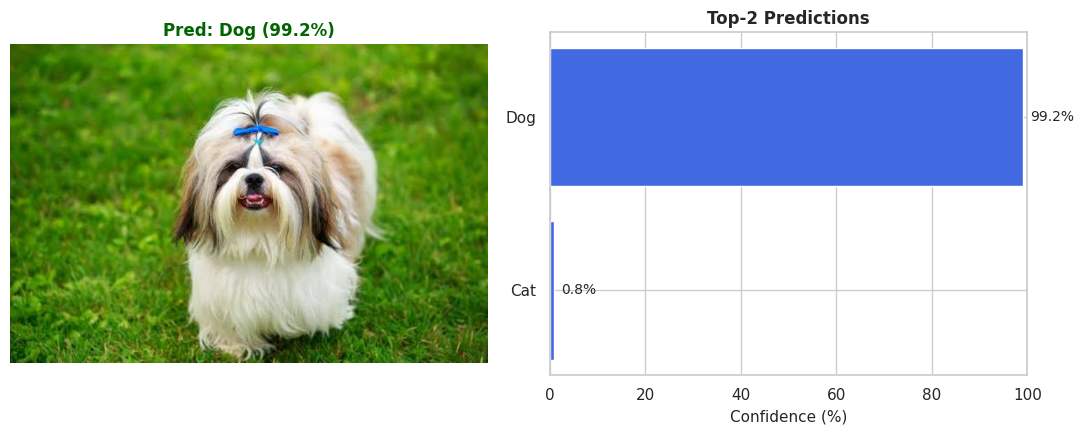

In [44]:
import io
import requests

def load_image_from_source(source: Union[str, Path]) -> Image.Image:
    """Loads an image from either a web URL or a local file path."""
    src_str = str(source).strip()
    if src_str.startswith("http://") or src_str.startswith("https://"):
        headers = {"User-Agent": "Mozilla/5.0"}
        response = requests.get(src_str, headers=headers, timeout=10)
        response.raise_for_status()
        img = Image.open(io.BytesIO(response.content))
    else:
        file_path = Path(src_str)
        if not file_path.exists():
            raise FileNotFoundError(f"Image not found at: {file_path}")
        img = Image.open(file_path)

    return img.convert("RGB")


def predict_single_image(
    model: nn.Module,
    image_source: Union[str, Path],
    class_names: List[str],
    transform:  None,
    device: Optional[Union[str, torch.device]] = None,
    top_k: int = 5,
) -> Tuple[str, float, List[Tuple[str, float]]]:
    """Predicts a single image and returns (pred_class, confidence, top_k_predictions)."""
    if device is None:
        device = next(model.parameters()).device
    model = model.to(device)
    model.eval()

    img = load_image_from_source(image_source)


    img_tensor = transform(img).unsqueeze(0).to(device)

    with torch.inference_mode():
        logits = model(img_tensor)
        if logits.ndim > 1 and logits.shape[-1] > 1:
            probs = torch.softmax(logits, dim=-1).squeeze(0)
        else:
            prob = torch.sigmoid(logits.squeeze(-1)).item()
            probs = torch.tensor([1.0 - prob, prob], device=device)

    k = min(top_k, len(class_names))
    top_probs, top_indices = torch.topk(probs, k=k)

    top_predictions = [
        (class_names[idx.item()], prob.item() * 100.0)
        for prob, idx in zip(top_probs, top_indices)
    ]

    best_pred_class = top_predictions[0][0]
    best_confidence = top_predictions[0][1]

    return best_pred_class, best_confidence, top_predictions


def plot_single_prediction(
    model: nn.Module,
    image_source: Union[str, Path],
    class_names: List[str],
    transform:  None,
    top_k: int = 5,
) -> None:
    """Visualizes single image prediction with an adjacent Top-K confidence bar chart."""
    img = load_image_from_source(image_source)
    best_class, best_conf, top_preds = predict_single_image(
        model=model,
        image_source=image_source,
        class_names=class_names,
        transform=transform,
        top_k=top_k,
    )

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    # Display image
    axes[0].imshow(img)
    axes[0].set_title(f"Pred: {best_class} ({best_conf:.1f}%)", fontsize=12, fontweight="bold", color="darkgreen")
    axes[0].axis("off")

    # Display Top-K probabilities
    labels = [item[0] for item in reversed(top_preds)]
    scores = [item[1] for item in reversed(top_preds)]

    axes[1].barh(labels, scores, color="royalblue")
    axes[1].set_xlabel("Confidence (%)", fontsize=11)
    axes[1].set_xlim(0, 100)
    axes[1].set_title(f"Top-{len(top_preds)} Predictions", fontsize=12, fontweight="bold")
    for idx, score in enumerate(scores):
        axes[1].text(score + 1.5, idx, f"{score:.1f}%", va="center", fontsize=10)

    plt.tight_layout()
    plt.show()


def plot_folder_predictions(
    model: nn.Module,
    folder_path: Union[str, Path],
    class_names: List[str],
    transform: None,
    num_images: int = 12,
    cols: int = 4,
) -> None:
    """Finds images in a local folder and plots a grid of predicted outputs."""
    folder = Path(folder_path)
    if not folder.exists() or not folder.is_dir():
        raise NotADirectoryError(f"Directory not found: {folder}")

    valid_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    image_paths = [p for p in folder.rglob("*.*") if p.suffix.lower() in valid_extensions]

    if not image_paths:
        print(f"⚠️ No image files found in '{folder_path}'.")
        return

    selected_paths = image_paths[:num_images]
    rows = (len(selected_paths) + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.5, rows * 3.5))
    axes = axes.flatten() if len(selected_paths) > 1 else [axes]

    for idx, img_p in enumerate(selected_paths):
        pred_cls, conf, _ = predict_single_image(
            model=model,
            image_source=img_p,
            class_names=class_names,
            transform=transform,
        )
        img = Image.open(img_p).convert("RGB")
        axes[idx].imshow(img)
        axes[idx].set_title(f"Pred: {pred_cls}\n({conf:.1f}%)", fontsize=10, fontweight="bold", color="darkgreen")
        axes[idx].axis("off")

    for j in range(len(selected_paths), len(axes)):
        axes[j].axis("off")

    plt.suptitle(f"Predictions from: {folder.name}", fontsize=14, y=1.02, fontweight="bold")
    plt.tight_layout()
    plt.show()


def predict_and_plot(
    model: nn.Module,
    target: Union[str, Path],
    class_names: List[str],
    transform:  None,
    top_k: int = 5,
    num_images: int = 12,
) -> None:
    """Entry point that automatically distinguishes between URL/file and folder path."""
    target_path = Path(str(target))
    if target_path.exists() and target_path.is_dir():
        plot_folder_predictions(
            model=model,
            folder_path=target_path,
            class_names=class_names,
            transform=transform,
            num_images=num_images,
        )
    else:
        plot_single_prediction(
            model=model,
            image_source=target,
            class_names=class_names,
            transform=transform,
            top_k=top_k,
        )


# Run inference and visualization on the target image
target_image_url = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcT0kVhIriLHNUZwjUCnaueqwqaXQ37IVXDohPBsX91S2A&s=10"
predict_and_plot(
    model=model,
    target=target_image_url,
    class_names=class_names,
    transform=transform,
)